# 04 · Chemical space

What compounds actually show up in ORD reactions? This notebook looks at the most frequent reactant and product compounds and renders them with RDKit.

In [1]:
from dotenv import load_dotenv
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Scaffolds import MurckoScaffold

from ord_analysis.db import get_engine
from ord_analysis import queries

load_dotenv()
engine = get_engine()

## Most frequent products

In [2]:
top_products = queries.top_compounds(engine, role="PRODUCT", limit=12)
top_products

,smiles,count
0,FC(C1=CC=C(N2CCOCC2)C=C1)(F)F,33792
1,C1(N2CCC(C3=CC=CC=C3)CC2)=CC=CN=C1,16896
2,Cl,10321
3,CC(C=C1)=C(C2=CC=C(N=CC=C3)C3=C2)C4=C1N(C5OCCC...,5760
4,Cn1cnc(C#N)c1-c1ccccc1F,2008
5,N#CC1=C(C2=CC=CC=C2F)N(C)C=N1,1984
6,N,1468
7,OC1=C(O)C(CC=C)=CC=C1CC=C,1227
8,OC1=C(O)C(CC=C)=C(CC=C)C=C1,1227
9,[Cl-],1010


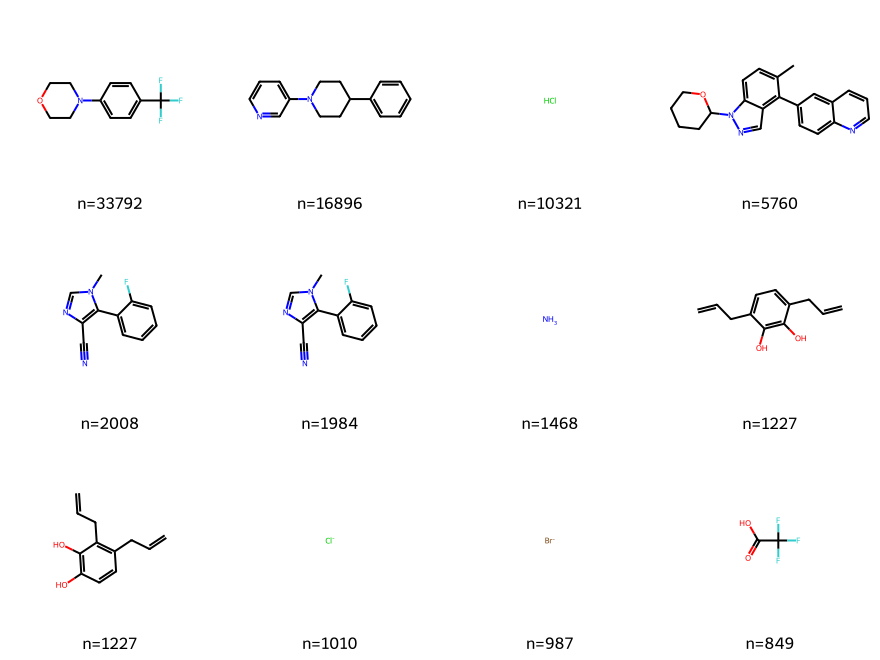

In [3]:
mols = [Chem.MolFromSmiles(s) for s in top_products["smiles"]]
legends = [f"n={c}" for c in top_products["count"]]
Draw.MolsToGridImage(mols, molsPerRow=4, subImgSize=(220, 220), legends=legends)

## Scaffold diversity

A quick look at how many distinct Bemis-Murcko scaffolds these top products reduce to -- a cheap proxy for how structurally diverse (vs. how repetitive/analog-series-like) the most common products are.

In [4]:
def murcko_scaffold_smiles(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return Chem.MolToSmiles(MurckoScaffold.GetScaffoldForMol(mol))

top_products["scaffold"] = top_products["smiles"].map(murcko_scaffold_smiles)
n_scaffolds = top_products["scaffold"].nunique()
print(f"{n_scaffolds} distinct scaffolds among the top {len(top_products)} products")

6 distinct scaffolds among the top 12 products


## Most frequent inputs, by reaction role

The same "most frequent compound" analysis as above, but for reaction *inputs* rather than products -- reactants, reagents, solvents, and catalysts each queried separately via `Compound.reaction_role`.

### Reactants

In [5]:
top_reactants = queries.top_input_compounds(engine, role="REACTANT", limit=12)
top_reactants

,smiles,count
0,O,225174
1,Cl,220164
2,[Na+],121522
3,C(C)N(CC)CC,95992
4,[OH-].[Na+],95363
5,CO,88568
6,C1CCOC1,88140
7,[K+],78540
8,CN(C)C=O,76942
9,ClCCl,72928


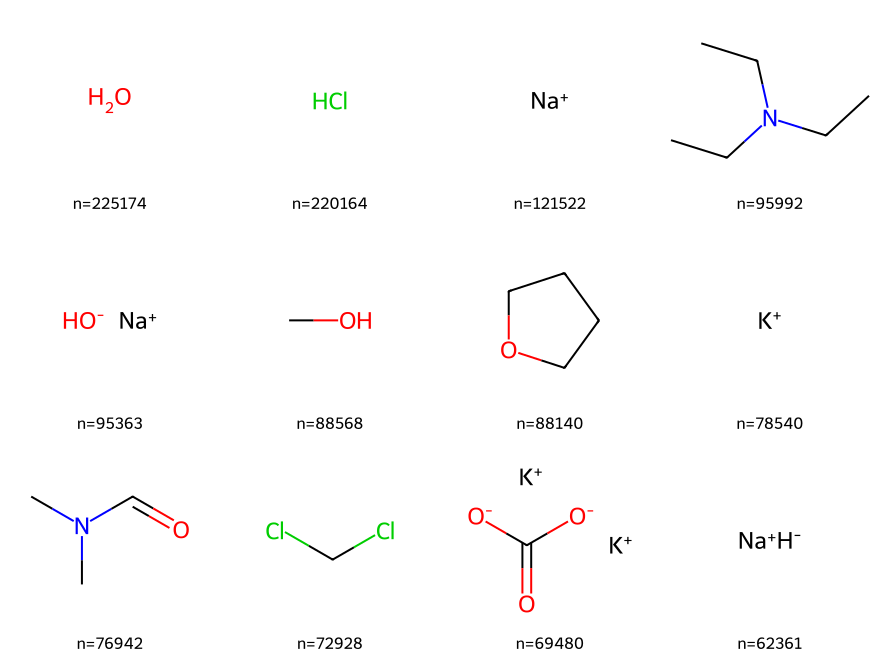

In [6]:
mols = [Chem.MolFromSmiles(s) for s in top_reactants["smiles"]]
legends = [f"n={c}" for c in top_reactants["count"]]
Draw.MolsToGridImage(mols, molsPerRow=4, subImgSize=(220, 220), legends=legends)

### Reagents

In [7]:
top_reagents = queries.top_input_compounds(engine, role="REAGENT", limit=12)
top_reagents

,smiles,count
0,CCN(C(C)C)C(C)C,27965
1,CC(C)(C)[O-].[Na+],11560
2,CCN=C=NCCCN(C)C.Cl,9991
3,C1CCC(CC1)N=C=NC2CCCCC2,8065
4,CN1CCOCC1,7961
5,C[Si](C)(C)[O-].[Na+],7680
6,CC(C)(C)[O-].[K+],6567
7,CCN(CC)CC,6211
8,C1=CC=C2C(=C1)N=NN2O,5988
9,O=P([O-])([O-])[O-].[K+],5376


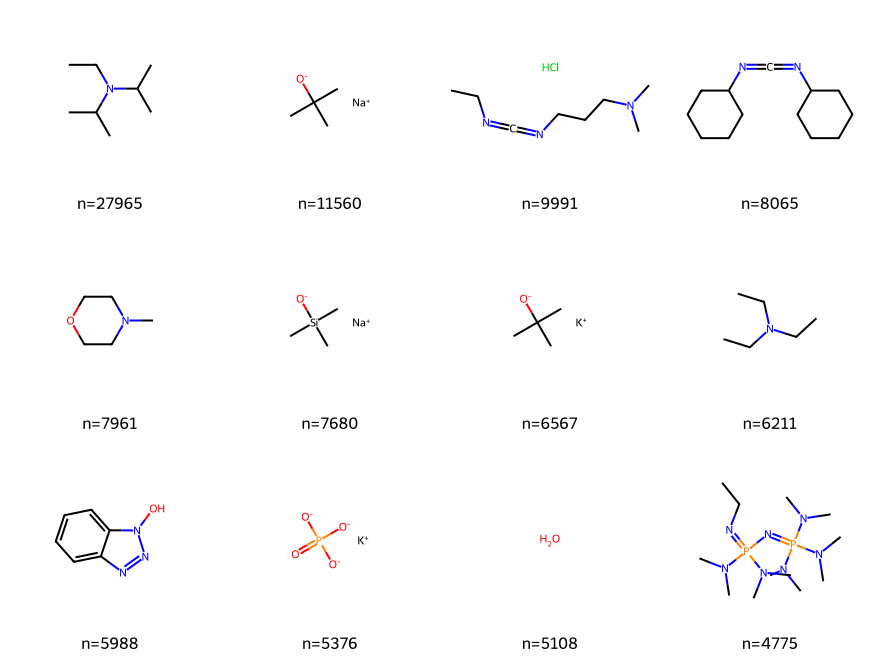

In [8]:
mols = [Chem.MolFromSmiles(s) for s in top_reagents["smiles"]]
legends = [f"n={c}" for c in top_reagents["count"]]
Draw.MolsToGridImage(mols, molsPerRow=4, subImgSize=(220, 220), legends=legends)

### Solvents

In [9]:
top_solvents = queries.top_input_compounds(engine, role="SOLVENT", limit=12)
top_solvents

,smiles,count
0,CN(C)C=O,411438
1,O,315523
2,CC#N,275802
3,CS(C)=O,250384
4,C1CCOC1,173026
5,CO,158320
6,C(Cl)Cl,154315
7,O1CCCC1,124050
8,ClCCl,109244
9,C(C)O,105567


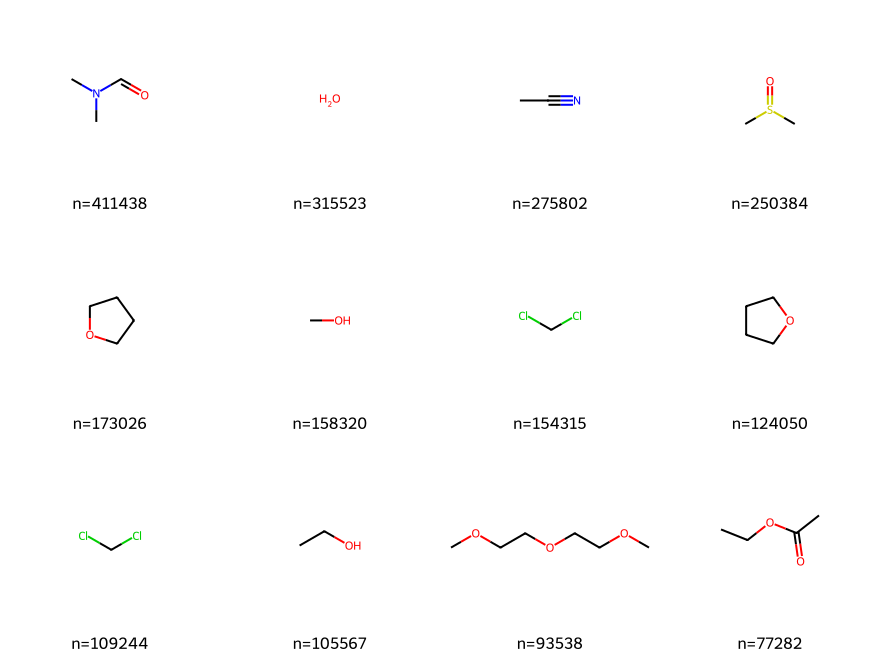

In [10]:
mols = [Chem.MolFromSmiles(s) for s in top_solvents["smiles"]]
legends = [f"n={c}" for c in top_solvents["count"]]
Draw.MolsToGridImage(mols, molsPerRow=4, subImgSize=(220, 220), legends=legends)

### Catalysts

In [11]:
top_catalysts = queries.top_input_compounds(engine, role="CATALYST", limit=12)
top_catalysts

,smiles,count
0,[Pd],49751
1,C=1C=CC(=CC1)[P](C=2C=CC=CC2)(C=3C=CC=CC3)[Pd]...,23292
2,[Cu]I,14764
3,C=1C=CC(=CC1)/C=C/C(=O)/C=C/C2=CC=CC=C2.C=1C=C...,10643
4,Cl[Pd]([P](C1=CC=CC=C1)(C2=CC=CC=C2)C3=CC=CC=C...,10178
5,CC(=O)[O-].CC(=O)[O-].[Pd+2],9734
6,C(C)(=O)[O-].[Pd+2].C(C)(=O)[O-],8931
7,CN(C1=CC=NC=C1)C,8183
8,[Zn],7865
9,CN(C)C=1C=CN=CC1,7551


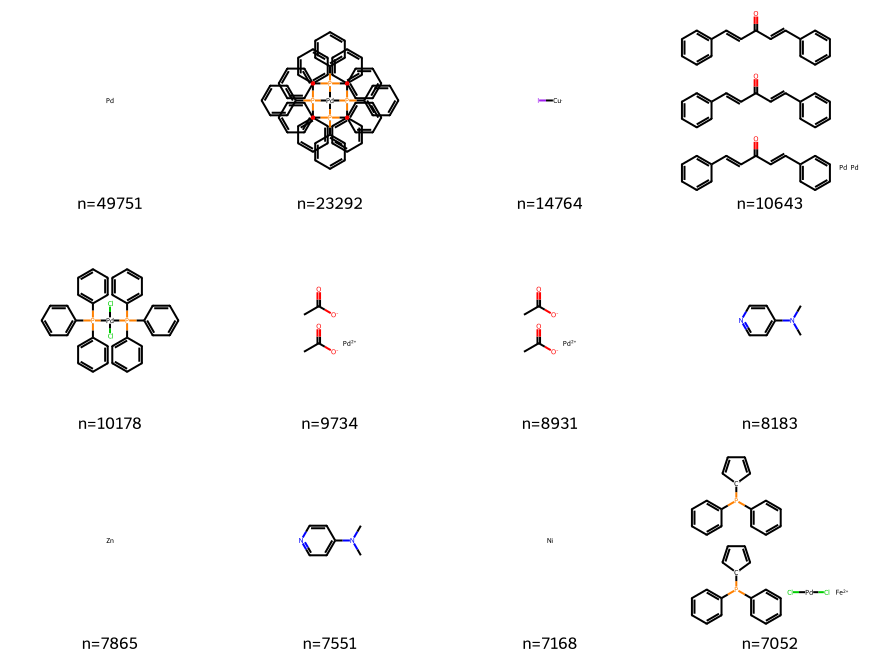

In [12]:
mols = [Chem.MolFromSmiles(s) for s in top_catalysts["smiles"]]
legends = [f"n={c}" for c in top_catalysts["count"]]
Draw.MolsToGridImage(mols, molsPerRow=4, subImgSize=(220, 220), legends=legends)